In [1]:
import numpy as np
np.random.seed(42)
m=100
X=2* np.random.rand(m,1)
Y=4+3*X+np.random.randn(m,1)

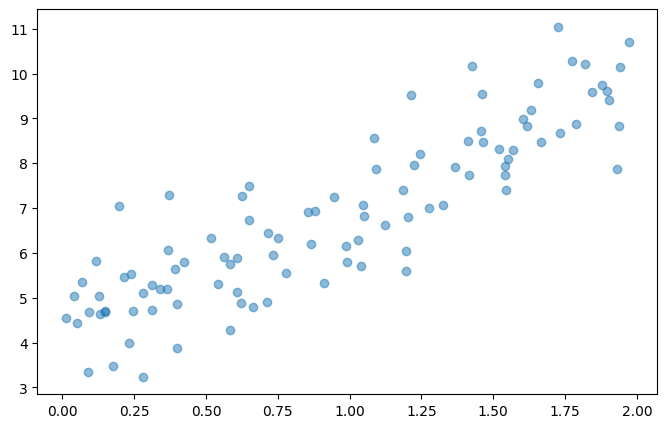

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, alpha=0.5, label="datos")

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y

print(theta_best)


[[4.21509616]
 [2.77011339]]


In [4]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
print(y_predict)

[[4.21509616]
 [9.75532293]]


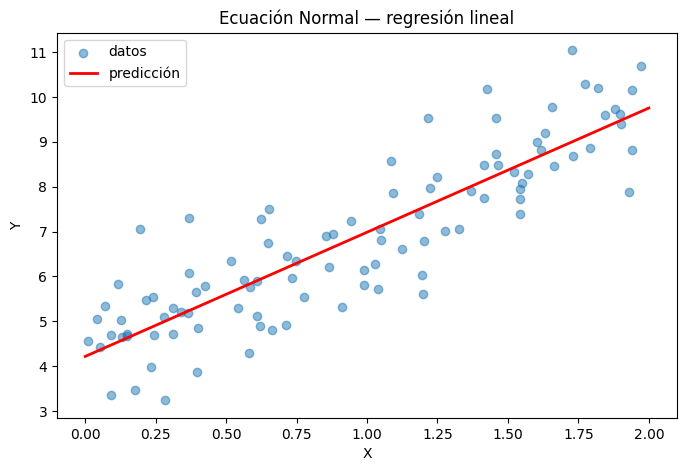

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, alpha=0.5, label="datos")
plt.plot([0, 2], y_predict, "r-", linewidth=2, label="predicción")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Ecuación Normal — regresión lineal")
plt.show()

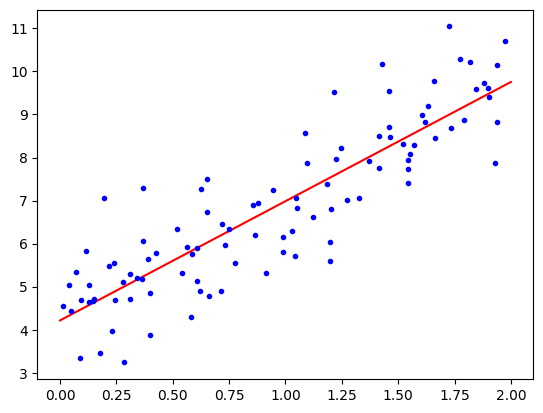

In [6]:
plt.plot(X_new, y_predict, 'r-', label= "predictions")
plt.plot(X, Y,"b.")
[...]
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,Y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [8]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

In [9]:
theta_best_svd , residuals, rank, s = np.linalg.lstsq(X_b, Y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [10]:
np.linalg.pinv(X_b) @ Y

array([[4.21509616],
       [2.77011339]])

In [11]:

eta=0.1
n_epochs=1000
m=len(X_b)
np.random.seed(42)
theta = np.random.rand(2,1)

for epoch in range(n_epochs):
    gradients = 2/ m*X_b.T @(X_b @ theta - Y)
    theta= theta - eta * gradients

print(theta)

[[4.21509616]
 [2.77011339]]


In [12]:
n_epochs = 50
t0, t1 = 5, 50
def learning_schedule(t):
    return t0/ (t+t1)


np.random.seed(42)
theta = np.random.rand(2,1)

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index= np.random.randint(m)
        xi=X_b[random_index : random_index+1]
        yi=Y[random_index: random_index +1]
        gradients = 2* xi.T @ (xi @theta -yi)
        eta=learning_schedule(epoch*m+iteration)
        theta= theta - eta * gradients

print(theta)




[[4.21047895]
 [2.74881457]]


In [13]:
from sklearn.linear_model import SGDRegressor

sdg_reg = SGDRegressor(max_iter = 1000, tol= 1e-5, penalty=None, eta0= 0.01, n_iter_no_change=100, random_state=42)
sdg_reg.fit(X, Y.ravel())
print(sdg_reg.intercept_, sdg_reg.coef_)

[4.21278812] [2.77270267]


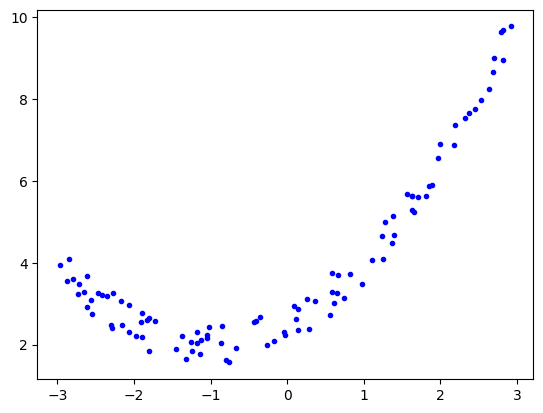

In [20]:
#regresion polinomial
np.random.seed(42)
m =100
X = 6 *np.random.rand(m,1) -3
y = 0.5 * X **2 +X+2+np.random.rand(m,1)
plt.plot(X,y,"b.")

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X_poly)

[[-7.52759287e-01  5.66646544e-01]
 [ 2.70428584e+00  7.31316190e+00]
 [ 1.39196365e+00  1.93756281e+00]
 [ 5.91950905e-01  3.50405874e-01]
 [-2.06388816e+00  4.25963433e+00]
 [-2.06403288e+00  4.26023172e+00]
 [-2.65149833e+00  7.03044338e+00]
 [ 2.19705687e+00  4.82705891e+00]
 [ 6.06690070e-01  3.68072842e-01]
 [ 1.24843547e+00  1.55859111e+00]
 [-2.87649303e+00  8.27421218e+00]
 [ 2.81945911e+00  7.94934969e+00]
 [ 1.99465584e+00  3.97865194e+00]
 [-1.72596534e+00  2.97895634e+00]
 [-1.90905020e+00  3.64447265e+00]
 [-1.89957294e+00  3.60837736e+00]
 [-1.17454654e+00  1.37955958e+00]
 [ 1.48538590e-01  2.20637127e-02]
 [-4.08329888e-01  1.66733298e-01]
 [-1.25262516e+00  1.56906979e+00]
 [ 6.71117368e-01  4.50398522e-01]
 [-2.16303684e+00  4.67872835e+00]
 [-1.24713211e+00  1.55533850e+00]
 [-8.01828940e-01  6.42929649e-01]
 [-2.63580095e-01  6.94744663e-02]
 [ 1.71105577e+00  2.92771184e+00]
 [-1.80195731e+00  3.24705014e+00]
 [ 8.54066305e-02  7.29429253e-03]
 [ 5.54487413e-01  3

In [21]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)
print(lin_reg.intercept_ , lin_reg.coef_)

[2.49786712] [[0.9943591  0.49967213]]


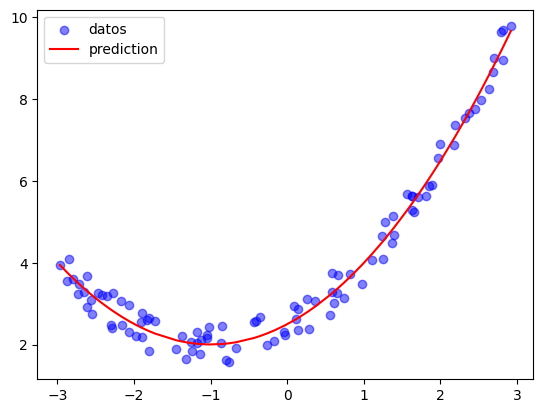

In [25]:
X_sorted = np.sort(X, axis=0)
X_sorted_poly = poly_features.transform(X_sorted)
y_predict = lin_reg.predict(X_sorted_poly)
plt.scatter(X,y,color="blue", alpha=0.5, label="datos")
plt.plot(X_sorted,y_predict, "r-", label = "prediction")
plt.legend()

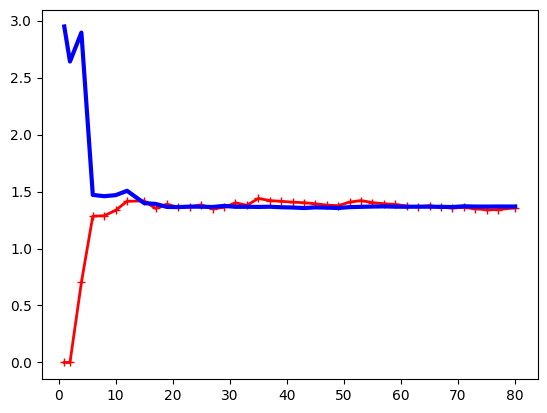

In [34]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(), X,y,train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error"

)

train_errors= -train_scores.mean(axis=1)
valid_errros= -valid_scores.mean(axis=1)

plt.plot(train_sizes,train_errors, "r-+", linewidth=2, label ='train')
plt.plot(train_sizes, valid_errros, "b-", linewidth=3, label ='valid')
[...]
plt.show()


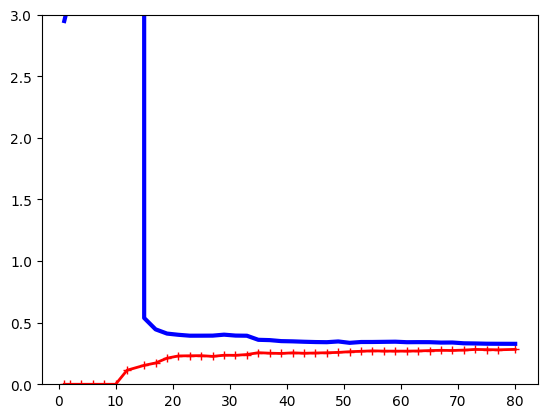

In [37]:
from sklearn.pipeline import make_pipeline
polynomial_regression = make_pipeline(

PolynomialFeatures(degree=10,include_bias=False),
LinearRegression()

)

train_sizes,train_scores,valid_scores = learning_curve(
    polynomial_regression, X,y,
    train_sizes=np.linspace(0.01, 1.0, 40), cv=5,
    scoring="neg_root_mean_squared_error",
)
train_errors= -train_scores.mean(axis=1)
valid_errros= -valid_scores.mean(axis=1)
plt.ylim([0, 3])
plt.plot(train_sizes,train_errors, "r-+", linewidth=2, label ='train')
plt.plot(train_sizes, valid_errros, "b-", linewidth=3, label ='valid')
[...]
plt.show()